# Linear Regression — A Step-by-Step Guide

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/01_linear_regression.ipynb)


## What is Linear Regression?

Linear Regression is one of the oldest and most widely used algorithms in machine learning and statistics. At its heart, it answers a simple question:

> **"Given some input values, can I predict a continuous output value?"**

For example:
- Given the **size of a house**, can I predict its **price**?
- Given a **patient's age and BMI**, can I predict their **medical expenses**?





The simplest form — **Simple Linear Regression** — models the relationship between one input feature $x$ and one output $y$ using a straight line:

$$\hat{y} = \beta_0 + \beta_1 x$$

Where:
- $\hat{y}$ → predicted output
- $\beta_0$ → **intercept** (where the line crosses the y-axis)
- $\beta_1$ → **slope** (how much $y$ changes per unit increase in $x$)

When we have **multiple features** ($x_1, x_2, ..., x_n$), this extends to:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$



## What Does "Fitting" Mean?

The model **learns** by finding the values of $\beta$ (coefficients) that minimize the **Mean Squared Error (MSE)**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

This is called the **Ordinary Least Squares (OLS)** method — we're literally minimizing the squared distances between actual and predicted values.



## A Critical Assumption: Correlation

Linear Regression **assumes** a linear relationship between features and the target. If your features have **no correlation** with the target, the model will perform poorly — garbage in, garbage out.

This is why **Exploratory Data Analysis (EDA)** always comes before modelling. We need to *see* whether fitting a line even makes sense.

Let's now build this up step by step. 

---
## Step 1 — Import Libraries

In [1]:
# !uv add numpy
# !uv add pandas
# !uv add matplotlib
# !uv add seaborn
# !uv add scikit-learn
# !uv add scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Helper functions
def plot_target_distribution(series, title='Target Distribution'):
    """Histogram + boxplot side by side for any target series."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(series, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(series.mean(), color='red', linestyle='--',
                    label=f'Mean = {series.mean():.1f}')
    axes[0].set_title('Histogram', fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    axes[1].boxplot(series, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_title('Boxplot', fontweight='bold')
    axes[1].set_ylabel('Value')
    axes[1].set_xticks([1])
    axes[1].set_xticklabels(['target'])

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Mean: {series.mean():.2f}  |  Std: {series.std():.2f}  "
          f"|  Min: {series.min()}  |  Max: {series.max()}")


def plot_correlation_heatmap(df, title='Correlation Matrix'):
    """Lower-triangle heatmap of the full correlation matrix."""
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                mask=mask, linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8})
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def plot_feature_target_correlation(df, target_col='target', threshold=0.3):
    """Horizontal bar chart of each feature's Pearson correlation with the target."""
    target_corr = df.corr()[target_col].drop(target_col).sort_values()
    colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr.values]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(target_corr.index, target_corr.values,
                    color=colors, edgecolor='white', height=0.6)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.axvline( threshold, color='green', linewidth=1, linestyle=':',
                alpha=0.7, label=f'|r| = {threshold} threshold')
    plt.axvline(-threshold, color='green', linewidth=1, linestyle=':', alpha=0.7)
    plt.xlabel('Pearson Correlation with Target')
    plt.title(f'Feature Correlation with {target_col}', fontweight='bold')
    plt.legend()

    for bar, val in zip(bars, target_corr.values):
        plt.text(val + 0.01 * np.sign(val),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)
    plt.tight_layout()
    plt.show()
    return target_corr


def plot_scatter_grid(df, features, target_col='target', threshold=0.3):
    """Grid of scatter plots (feature vs target) with a regression line each.
    Features with |r| >= threshold are highlighted in blue; others in gray."""
    n = len(features)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        r = df[feature].corr(df[target_col])
        color = 'steelblue' if abs(r) >= threshold else 'lightgray'

        axes[i].scatter(df[feature], df[target_col],
                        alpha=0.4, s=20, color=color)
        m, b = np.polyfit(df[feature], df[target_col], 1)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target_col if i % ncols == 0 else '')
        axes[i].set_title(f'{feature}\nr = {r:.3f}', fontweight='bold',
                          color='green' if abs(r) >= threshold else 'gray')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Scatter Plots: Each Feature vs Target  '
                 '(green title = strong correlation)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(y_true, y_pred, title='Actual vs Predicted', color='steelblue'):
    """Scatter plot of actual vs predicted values with a perfect-fit reference line."""
    r2 = r2_score(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color=color, s=25, label='Predictions')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit (y = x)')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{title}\nR\u00b2 = {r2:.3f}', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted_multi(datasets):
    """Side-by-side actual vs predicted for multiple datasets.

    Parameters
    ----------
    datasets : list of (y_true, y_pred, title, color)
    """
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
        r2 = r2_score(y_true, y_pred)
        ax.scatter(y_true, y_pred, alpha=0.5, color=color, s=25)
        mn = min(np.min(y_true), np.min(y_pred))
        mx = max(np.max(y_true), np.max(y_pred))
        ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{title}\nR\u00b2 = {r2:.3f}', fontweight='bold')
        ax.legend(fontsize=9)

    plt.suptitle('Actual vs Predicted — Comparing Evaluation Strategies',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title='Residual Analysis'):
    """Three-panel residual diagnostic: scatter, histogram, Q-Q plot."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].scatter(y_pred, residuals, alpha=0.5, color='darkorange', s=25)
    axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Predicted', fontweight='bold')

    axes[1].hist(residuals, bins=25, color='darkorange', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Residual Value')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Residual Distribution', fontweight='bold')

    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot (should follow the line)', fontweight='bold')
    axes[2].get_lines()[1].set_color('red')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_coefficients(feature_names, coefficients, title='Regression Coefficients'):
    """Horizontal bar chart of model coefficients, colored by sign."""
    coef_df = pd.DataFrame({'Feature': feature_names,
                             'Coefficient': coefficients})
    coef_df = coef_df.sort_values('Coefficient')
    colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'],
                    color=colors, edgecolor='white', height=0.6)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient Value')
    plt.title(title, fontweight='bold')

    for bar, val in zip(bars, coef_df['Coefficient']):
        plt.text(val + 2 * np.sign(val),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)
    plt.tight_layout()
    plt.show()
    return coef_df


print("Plot helper functions defined.")

Plot helper functions defined.


---
## Step 2 — Load the Dataset

We'll use scikit-learn's built-in **Diabetes dataset**.

### About the Dataset

The dataset contains **442 patient records** collected from diabetes patients. Each record has:
- **10 features**: age, sex, BMI, average blood pressure, and 6 blood serum measurements (all normalized)
- **Target**: a quantitative measure of **disease progression** one year after baseline (a continuous value)

This makes it a perfect fit for regression. Our goal: predict disease progression from clinical measurements.

In [3]:
# Load dataset
dataset = load_diabetes()

# Create a DataFrame for easier handling
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {dataset.feature_names}")
print(f"\nTarget: disease progression score")
df.head()

# # Second dataset
# from sklearn.datasets import fetch_california_housing

# dataset = fetch_california_housing()
# df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
# df['target'] = dataset.target

# print(f"Dataset shape: {df.shape}")
# print(f"\nFeatures: {dataset.feature_names}")
# print(f"\nTarget: disease progression score")
# df.head()

Dataset shape: (442, 11)

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target: disease progression score


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [18]:
# simulating perfectly fitting dataset
from sklearn.datasets import make_regression
from sklearn.utils import Bunch
import numpy as np

X_raw, y = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=7,
    noise=20,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]

dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic regression dataset via make_regression"
)

# Now this works exactly like any sklearn dataset
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

---
## Step 3 — Exploratory Data Analysis (EDA)

Before we model anything, we explore the data. This step is **not optional** — it tells us:
1. What the data looks like (distribution of features and target)
2. Whether features are **correlated** with the target (essential for Linear Regression)
3. Whether there are obvious outliers or data quality issues

### 3.1 Basic Statistics

In [19]:
df.describe().round(3)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,-0.033,0.004,0.020,0.046,0.072,-0.001,0.005,-0.006,0.003,-0.055,-5.940
std,0.981,1.004,1.061,0.938,0.958,1.041,1.008,1.018,0.956,0.996,110.306
min,-2.839,-2.991,-2.940,-3.008,-3.177,-3.170,-3.241,-3.020,-2.703,-2.704,-338.276
25%,-0.772,-0.709,-0.679,-0.532,-0.508,-0.695,-0.682,-0.661,-0.608,-0.770,-81.144
50%,0.023,0.022,-0.025,0.097,0.024,0.019,0.024,-0.045,0.041,-0.043,-2.415
75%,0.674,0.643,0.750,0.680,0.688,0.666,0.642,0.691,0.640,0.598,66.017
max,2.602,3.138,2.985,3.079,3.853,3.926,3.152,2.755,3.077,3.243,328.787


### 3.2 Target Distribution

Let's see what we're trying to predict — the distribution of disease progression scores.

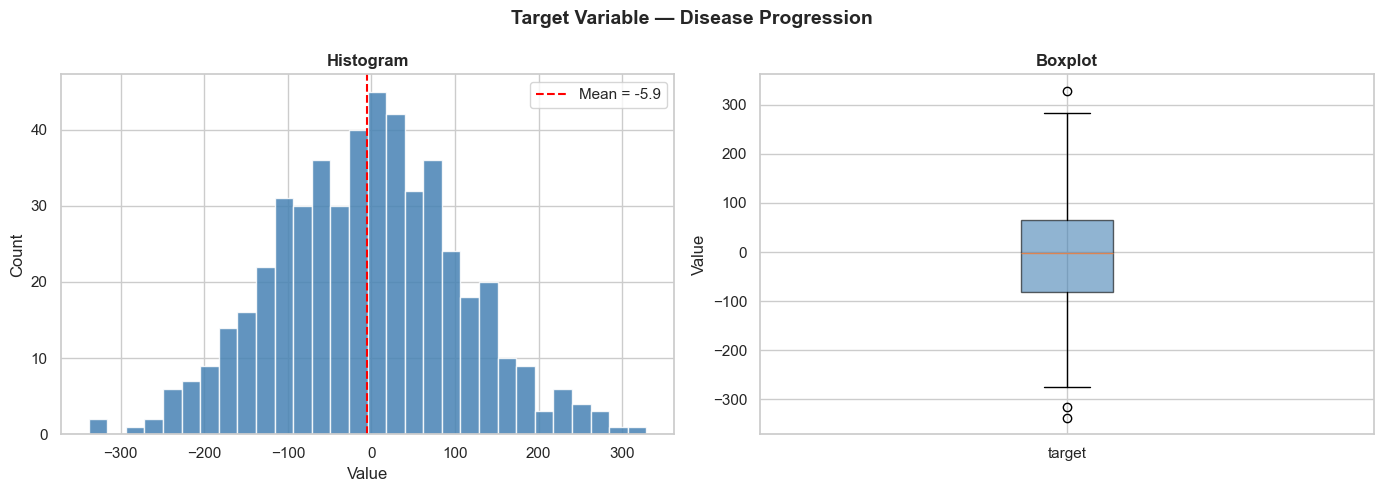

Mean: -5.94  |  Std: 110.31  |  Min: -338.27580333875954  |  Max: 328.7870305507173


In [20]:
plot_target_distribution(df['target'], title='Target Variable — Disease Progression')

### 3.3 Correlation — The Heart of Linear Regression

> **Why correlation matters so much?**
>
> Linear Regression works by drawing the *best fitting line* between features and the target. For this line to be meaningful, the features must **move together** with the target in a consistent direction — that's correlation.
>
> - A correlation close to **+1** → strong positive linear relationship
> - A correlation close to **-1** → strong negative linear relationship
> - A correlation close to **0** → no linear relationship — the feature is not useful for Linear Regression

Let's visualize the **correlation matrix** first.

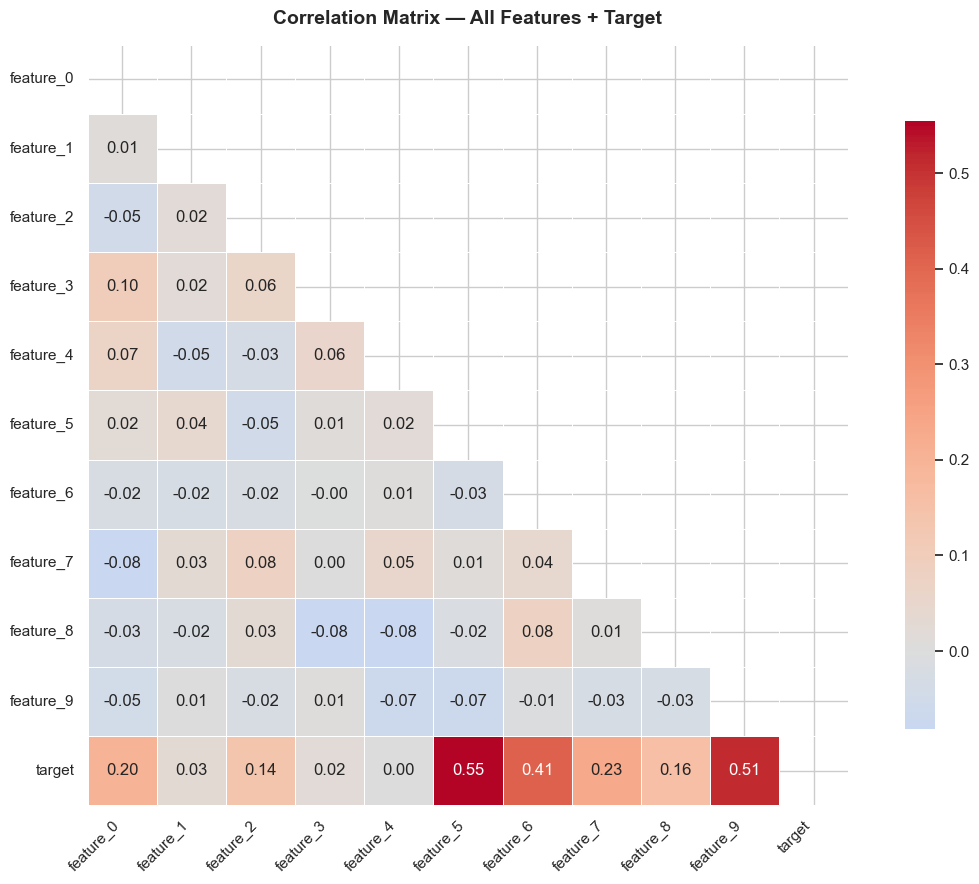

In [21]:
plot_correlation_heatmap(df, title='Correlation Matrix — All Features + Target')

### 3.4 Feature vs Target Correlation (Sorted)

Let's zoom in on what matters most — **how each feature correlates with the target**.

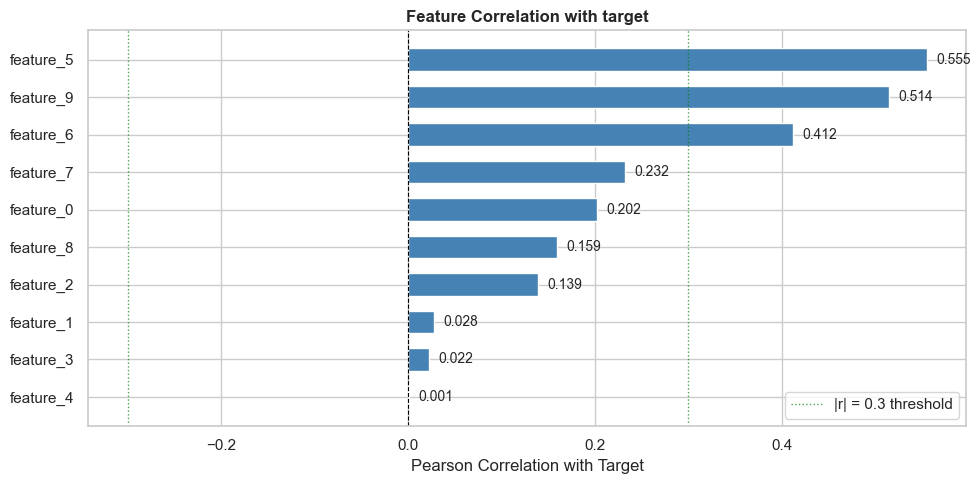


Correlation values with target:
feature_4    0.001
feature_3    0.022
feature_1    0.028
feature_2    0.139
feature_8    0.159
feature_0    0.202
feature_7    0.232
feature_6    0.412
feature_9    0.514
feature_5    0.555


In [22]:
target_corr = plot_feature_target_correlation(df, target_col='target', threshold=0.3)
print("\nCorrelation values with target:")
print(target_corr.round(3).to_string())

### 3.5 Scatter Plots — Visualizing the Linear Relationship

Numbers are good, but **scatter plots** show us the *shape* of the relationship. If the cloud of points roughly follows a line — we're good to go!

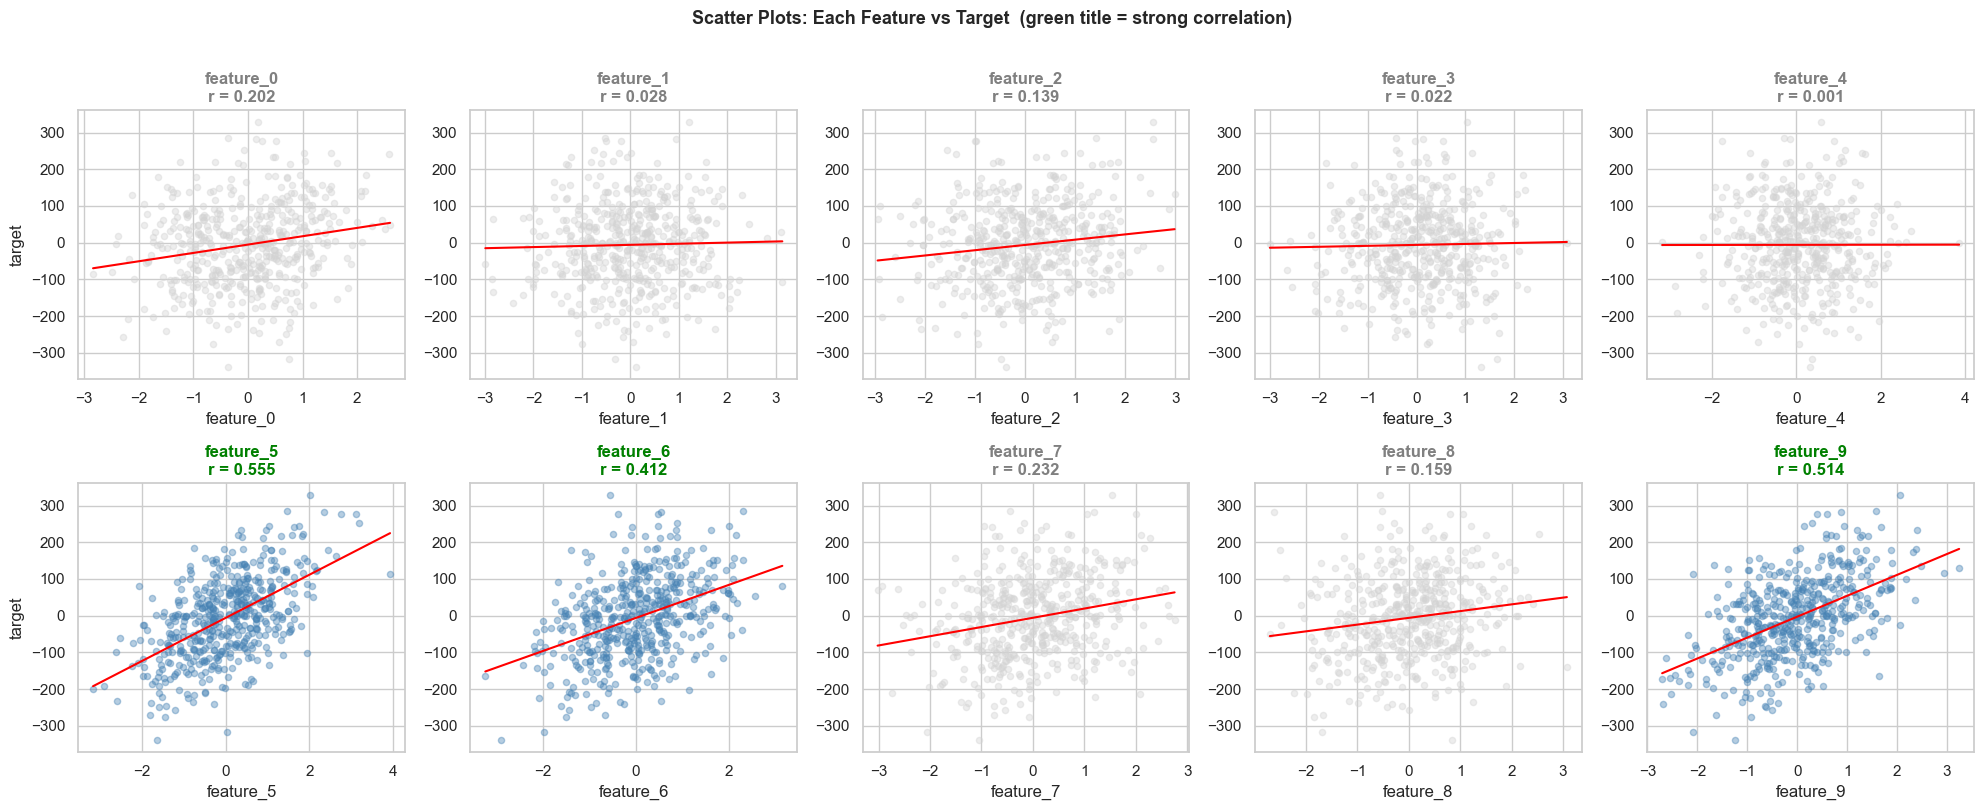

In [23]:
plot_scatter_grid(df, features=dataset.feature_names, target_col='target', threshold=0.3)

### 🔍 EDA Summary

From our exploration:
- **`bmi`** (r = 0.586) and **`s5`** (r = 0.565) have the **strongest positive correlations** with the target
- **`s1`** and **`s2`** show **negative correlations** — as these features increase, the disease progression tends to decrease
- **`sex`** has the weakest correlation — not very informative on its own

The scatter plots confirm that most features show a **rough linear trend** with the target — so Linear Regression is a reasonable choice here!

---

## Step 4 — Prepare Features and Target

In [24]:
X = df.drop(columns='target')   # Feature matrix
y = df['target']                 # Target vector

print(f"Feature matrix X : {X.shape}  — {X.shape[0]} samples x {X.shape[1]} features")
print(f"Target vector y  : {y.shape}  — {y.shape[0]} samples")

Feature matrix X : (500, 10)  — 500 samples x 10 features
Target vector y  : (500,)  — 500 samples


---
## Step 5 — Fit on the Entire Dataset (No Split)

> **Wait — why are we fitting on ALL the data first?**
>
> We're doing this **intentionally** as a teaching step.
>
> When you train on 100% of the data, the model can squeeze every bit of pattern out of it — including patterns that are just noise or quirks of *this particular dataset*. The metrics will look great. But the model hasn't been **tested** on data it has never seen. So we don't really know if it *generalizes*.
>
> We'll come back to this important point later and show why splitting is necessary.

For now, let's fit and see the results.

In [25]:
model_full = LinearRegression()
model_full.fit(X, y)

y_pred_full = model_full.predict(X)

print("Model trained on full dataset.")
print(f"\nIntercept (\u03b2\u2080): {model_full.intercept_:.4f}")
print(f"\nCoefficients (\u03b2\u2081 ... \u03b2\u2099):")
coef_full = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_full.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_full.to_string(index=False))

Model trained on full dataset.

Intercept (β₀): -1.9899

Coefficients (β₁ ... βₙ):
  Feature  Coefficient
feature_9    64.870618
feature_5    64.671819
feature_6    46.186427
feature_0    28.893124
feature_7    24.575092
feature_2    19.044813
feature_8    17.603503
feature_4     1.721295
feature_3    -1.464033
feature_1    -0.121076


### 5.1 Evaluate — Full Dataset Metrics

#### Metrics Glossary

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Average absolute error. In same units as target. |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Penalizes large errors more heavily. |
| **RMSE** | $\sqrt{\text{MSE}}$ | Square root of MSE. Comparable to target scale. |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained. 1.0 = perfect. |

In [26]:
def compute_metrics(y_true, y_pred, label):
    """Return a dict of regression metrics for a given set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


metrics_full = compute_metrics(y, y_pred_full, 'Full Data (No Split)')
print(f"  MAE  : {metrics_full['MAE']:.4f}")
print(f"  MSE  : {metrics_full['MSE']:.4f}")
print(f"  RMSE : {metrics_full['RMSE']:.4f}")
print(f"  R2   : {metrics_full['R2']:.4f}")

  MAE  : 15.8502
  MSE  : 391.1082
  RMSE : 19.7765
  R2   : 0.9678


### 5.2 Visualize — Actual vs Predicted

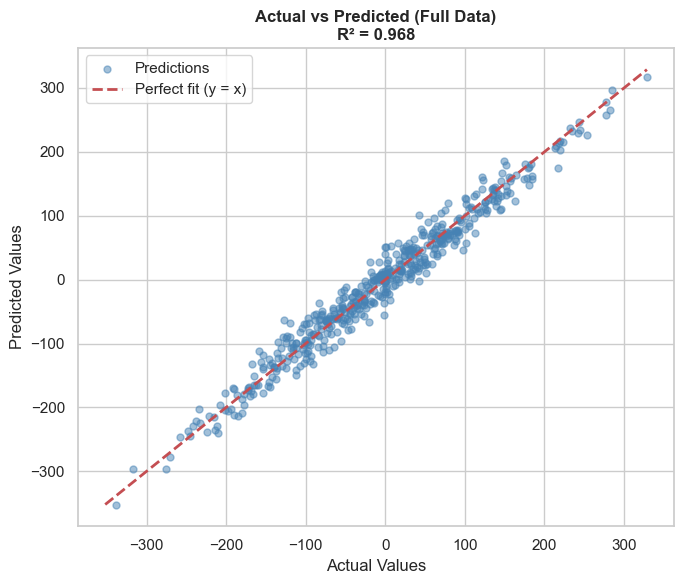

In [27]:
plot_actual_vs_predicted(y, y_pred_full,
                         title='Actual vs Predicted (Full Data)',
                         color='steelblue')

---
## Step 6 — Why the Full-Data Approach is Problematic 

The metrics above look decent. But here's the catch:

> **We trained and tested on the same data.**
>
> This is like studying for an exam using *the actual exam paper*, then claiming you've mastered the subject. Of course you'll score well — but you haven't actually learned to generalise!

### What Could Go Wrong?

- The model might have **memorised** patterns specific to this dataset — called **overfitting**
- When given **new, unseen data**, it may perform significantly worse
- The R² score we computed is **optimistically biased** — it flatters the model

### The Solution — Train/Test Split

We split the data into two non-overlapping sets:

| Set | Purpose | Typical Size |
|-----|---------|-------------|
| **Training set** | Model learns from this | 80% |
| **Test set** | Evaluate generalization — model never sees this during training | 20% |

The test set **simulates real-world, unseen data**. If the model performs well on it, we can trust it.

---
## Step 7 — Proper 80/20 Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100
)

print(f"Training set : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Total        : {len(X)}")

Training set : 400 samples  (80%)
Test set     : 100  samples  (20%)
Total        : 500


---
## Step 8 — Fit on Training Data Only

In [29]:
model_split = LinearRegression()
model_split.fit(X_train, y_train)

y_pred_train = model_split.predict(X_train)
y_pred_test  = model_split.predict(X_test)

print("Model trained on training set only.")
print(f"Intercept (\u03b2\u2080): {model_split.intercept_:.4f}")

Model trained on training set only.
Intercept (β₀): -2.1204


---
## Step 9 — Compare Train vs Test Performance

The key insight: if **training metrics >> test metrics**, the model has overfit — it memorised instead of learning.

In [30]:
results = pd.DataFrame([
    compute_metrics(y,       y_pred_full,  'Full Data (No Split)'),
    compute_metrics(y_train, y_pred_train, 'Train Set (80%)'),
    compute_metrics(y_test,  y_pred_test,  'Test Set  (20%)'),
]).set_index('Set').round(4)

print(results.to_string())

                          MAE       MSE     RMSE      R2
Set                                                     
Full Data (No Split)  15.8502  391.1082  19.7765  0.9678
Train Set (80%)       15.0749  354.5737  18.8301  0.9711
Test Set  (20%)       18.8890  545.1047  23.3475  0.9530


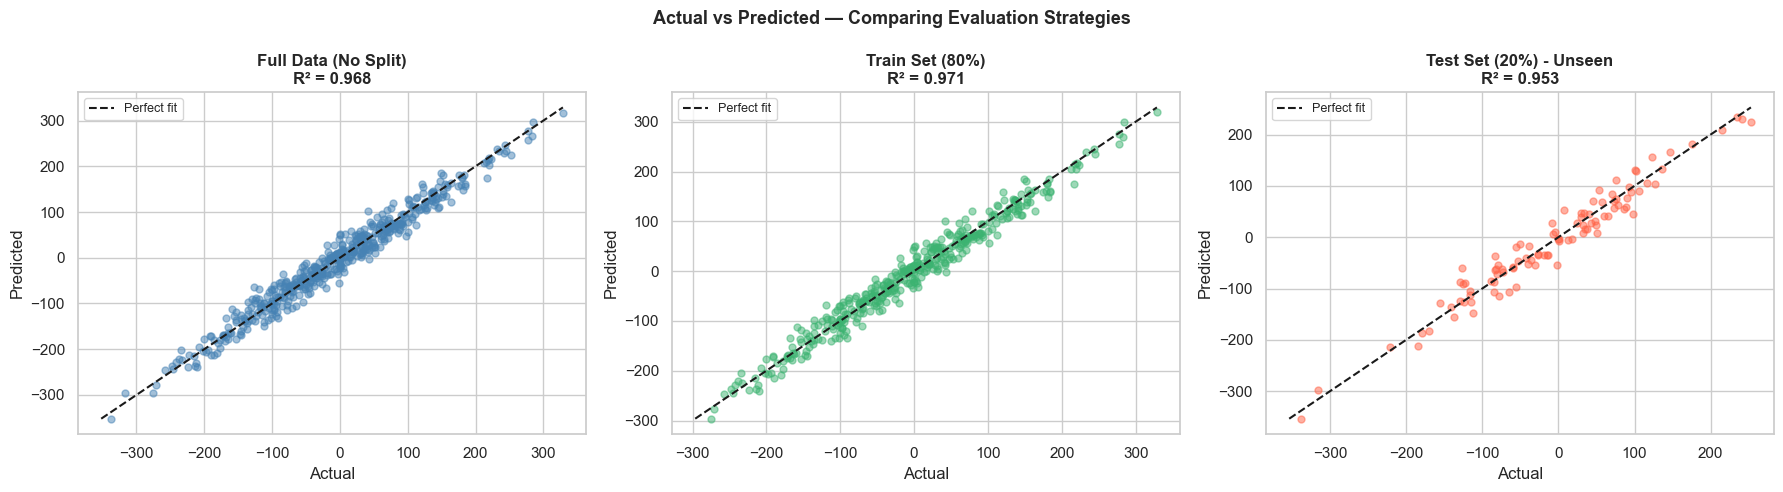

In [31]:
plot_actual_vs_predicted_multi([
    (y,       y_pred_full,  'Full Data (No Split)',    'steelblue'),
    (y_train, y_pred_train, 'Train Set (80%)',         'mediumseagreen'),
    (y_test,  y_pred_test,  'Test Set (20%) - Unseen', 'tomato'),
])

---
## Step 10 — Coefficient Interpretation

The coefficients tell us how much the prediction changes for a **one-unit increase** in each feature (holding others constant).

Since features in the Diabetes dataset are already **normalized** (zero mean, unit variance), coefficients are directly comparable.

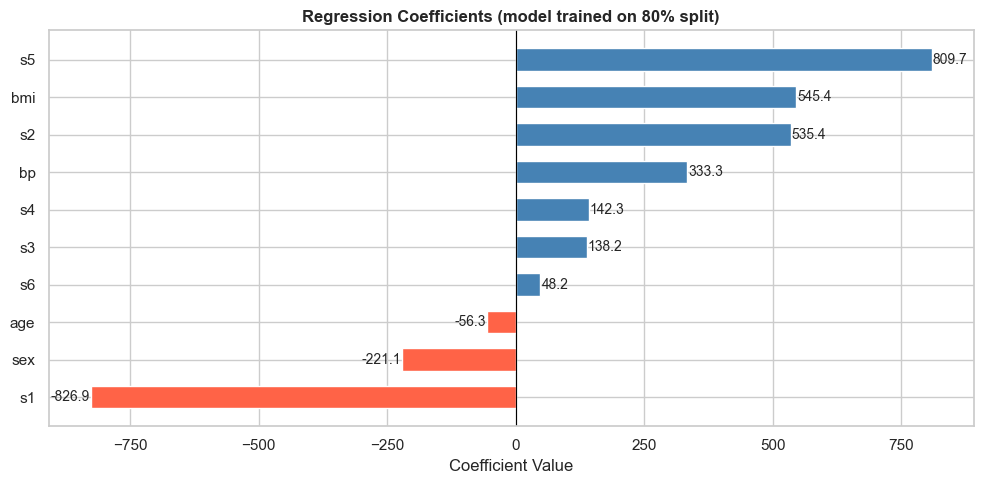


Positive drivers (increase disease progression):
Feature  Coefficient
     s5   809.681948
    bmi   545.398994
     s2   535.428126
     bp   333.314704
     s4   142.314688
     s3   138.169661
     s6    48.231088

Negative drivers (decrease disease progression):
Feature  Coefficient
     s1  -826.938758
    sex  -221.146581
    age   -56.332843


In [16]:
coef_df = plot_coefficients(
    feature_names=X.columns,
    coefficients=model_split.coef_,
    title='Regression Coefficients (model trained on 80% split)'
)

print("\nPositive drivers (increase disease progression):")
print(coef_df[coef_df['Coefficient'] > 0]
      .sort_values('Coefficient', ascending=False).to_string(index=False))
print("\nNegative drivers (decrease disease progression):")
print(coef_df[coef_df['Coefficient'] < 0]
      .sort_values('Coefficient').to_string(index=False))

---
## Step 11 — Residual Analysis

A well-behaved linear regression should have residuals that are:
- **Randomly scattered** around zero (no pattern)
- **Approximately normally distributed**
- **Constant variance** (homoscedastic)

If residuals show a pattern, it means the model is missing some structure in the data.

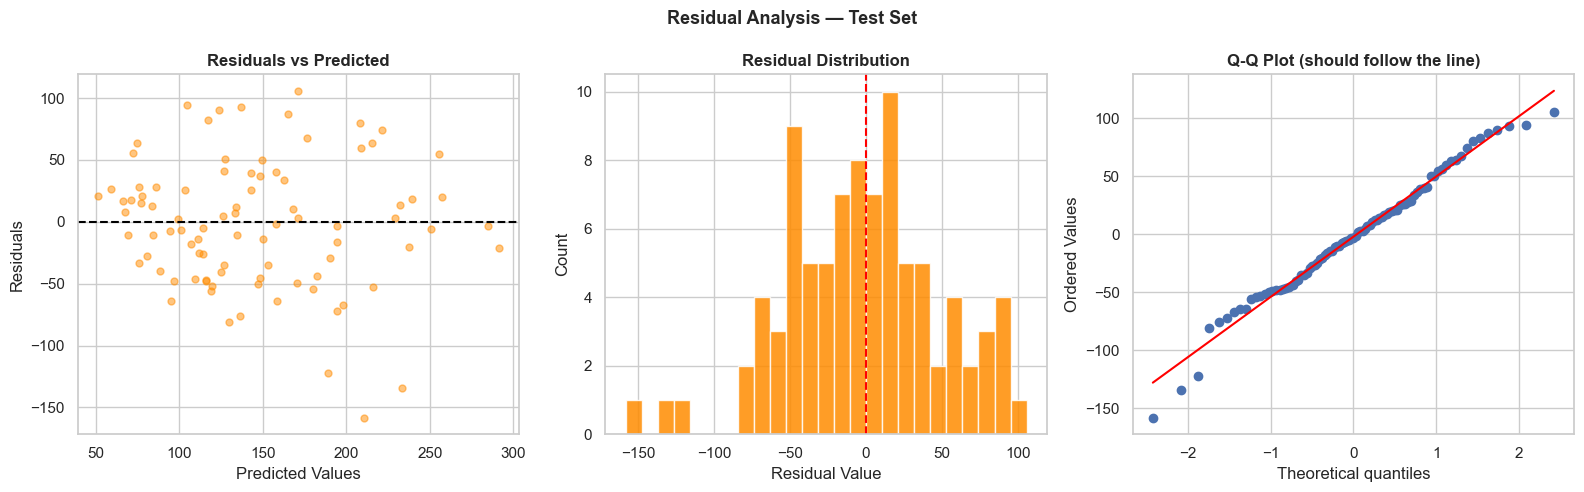

In [17]:
plot_residuals(y_test, y_pred_test, title='Residual Analysis — Test Set')

---
## Final Summary

Here's what we built and learned in this notebook:

### The Building Blocks

| Step | What We Did | Why It Matters |
|------|-------------|----------------|
| 1 | Imported libraries | Numpy, Pandas, Sklearn, Seaborn are our toolkit |
| 2 | Loaded the dataset | A clean, real-world regression dataset |
| 3 | EDA — distributions, correlations, scatter plots | **Correlation must exist** for Linear Regression to make sense |
| 4 | Prepared X and y | Separated features from the target |
| 5 | Fit on full dataset | Demonstrates the "training bias" trap |
| 6 | Understood the problem | Training = testing → overly optimistic metrics |
| 7 | 80/20 Train-Test Split | Proper way to evaluate generalization |
| 8 | Fit on training set | Model only learns from 80% |
| 9 | Compared metrics | Full data metrics vs honest test set metrics |
| 10 | Coefficient interpretation | Which features matter most |
| 11 | Residual analysis | Checks model assumptions |

### Key Takeaways

1. **Correlation is the foundation** — always check it before fitting a linear model
2. **Never evaluate on training data alone** — it gives a falsely optimistic picture
3. **The test set is sacred** — it should never influence model training or selection
4. **Residual plots reveal hidden problems** — always check them after fitting
5. **R² on test data is what matters** — that's your real-world performance estimate